# PSF Extraction and Modeling

In [ ]:
import os
import os.path
import glob
import numpy as np
from tqdm import tqdm
import math
import warnings
import argparse
import time
import shutil

#Numpy,matplotlib,etc.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
from IPython.display import Image

#Astropy
from astropy.visualization import ZScaleInterval
import astropy
from astropy.io import fits
import astropy.stats as stat
from astropy.stats import mad_std
from astropy.stats import sigma_clip
from astropy.modeling import models, fitting
from astropy.convolution import convolve
from astropy.visualization import SimpleNorm

from scipy.ndimage import shift
from scipy.signal import fftconvolve
from scipy.ndimage import gaussian_filter
import scipy.signal

import photutils.psf_matching as psf
from photutils.utils import calc_total_error
from photutils.psf import CircularGaussianSigmaPRF
from photutils.psf_matching import make_kernel, make_wiener_kernel, SplitCosineBellWindow
from photutils.aperture import aperture_photometry, ApertureStats, CircularAperture, CircularAnnulus
from photutils.detection import DAOStarFinder
from photutils.profiles import CurveOfGrowth

from skimage.registration import phase_cross_correlation

/opt/anaconda3/envs/Perkins/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def get_psf(target_image,star_bound,background_bound,size):
    '''
    This function takes the centroid of the area specified in a reference image (intended to be one star), 
    then takes the centroid of the same area in the specified list of images, 
    and calculates the shifts required to map them to the reference image.
    Inputs:
    ref_image (str): the filepath of the reference image
    target_image (str): the filepath of the target image
    star_bound (np array): the bounds for the box of which to centroid, in [[xmin,xmax],[ymin,ymax]] form
    background_bound (np array): the bounds for the box of which to calculate the background from, in [[xmin,xmax],[ymin,ymax]] form
    Outputs:
    xy_shift (list): the x and y shifts for the target image
    '''
    
    #Calculate the shifts as compared to the reference centroid
    
    #Set our sum arrays to nothing
    img_x_weight = []
    img_y_weight = []
    img_no_weight = []
        
    #Converting the fits to a np.array
    img_fits = fits.getdata(target_image)

    #Extracing star+background patches
    img_background = img_fits[background_bound[1][0]:background_bound[1][1],background_bound[0][0]:background_bound[0][1]]
    img_star = img_fits[star_bound[1][0]:star_bound[1][1],star_bound[0][0]:star_bound[0][1]]
    #Calculating the background
    bg_med = np.nanmedian(img_background)
    bg_std = np.nanstd(img_background)
    threshhold = bg_med + 3*bg_std
    print(threshhold)
    # img_reduced = img_star - bg_med

    #plt.imshow(img_star,vmin=-1,vmax=5)
    #plt.colorbar()
        
    #Nested for loops for x/y weighted pixels
    for x in np.arange(0,img_star.shape[1]):
        for y in np.arange(0,img_star.shape[0]):
            if img_star[x,y] > threshhold:
                x_weight = (img_star[x,y]-bg_med)*x
                y_weight = (img_star[x,y]-bg_med)*y
                no_weight= img_star[x,y]-bg_med
                img_x_weight.append(x_weight)
                img_y_weight.append(y_weight)
                img_no_weight.append(no_weight)
                
    #Calculate the image's centroid
    print(sum(img_x_weight))
    print(sum(img_no_weight))
    img_x_centroid = sum(img_x_weight)/sum(img_no_weight)
    img_y_centroid = sum(img_y_weight)/sum(img_no_weight)
    img_centroid = [img_y_centroid,img_x_centroid]
    print(img_centroid)
    starbox = img_star[int(img_x_centroid)-size:int(img_x_centroid)+size+1, int(img_y_centroid)-size:int(img_y_centroid)+size+1]
    plt.imshow(starbox)
    plt.scatter(size+1,size+1, color='red',s=3)
    plt.colorbar



    y, x, = np.mgrid[:size*2+1, :size*2+1]
    f_init = models.Gaussian2D(amplitude = starbox[size+1,size+1]-np.median(img_background),x_mean=int(size+1), y_mean = int(size+1))
    fit_f = fitting.LevMarLSQFitter()

    f = fit_f(f_init, x, y, starbox-np.median(img_background))
    std_devs = np.array([f.x_stddev[0],f.y_stddev[0]])
    fwhm = 2.335*std_devs
    fwhm = np.sqrt(fwhm[0]**2+fwhm[1]**2)

    psf_fin = f(x,y)/np.sum(f(x,y))


    return img_centroid, psf_fin, starbox, fwhm
        
    # #Calculate the x/y shifts, print them, and add them to the list
    # x_shift = ref_centroid[0] - img_centroid[0]
    # y_shift = ref_centroid[1] - img_centroid[1]
    # xy_shift = [x_shift,y_shift]
#    # return xy_shift

In [ ]:
# def get_psf1(target_image,star_bound,background_bound,size):
#     '''
#     This function takes the centroid of the area specified in a reference image (intended to be one star), 
#     then takes the centroid of the same area in the specified list of images, 
#     and calculates the shifts required to map them to the reference image.
#     Inputs:
#     ref_image (str): the filepath of the reference image
#     target_image (str): the filepath of the target image
#     star_bound (np array): the bounds for the box of which to centroid, in [[xmin,xmax],[ymin,ymax]] form
#     background_bound (np array): the bounds for the box of which to calculate the background from, in [[xmin,xmax],[ymin,ymax]] form
#     Outputs:
#     xy_shift (list): the x and y shifts for the target image
#     '''
    
#     #Calculate the shifts as compared to the reference centroid
    
#     #Set our sum arrays to nothing
#     img_x_weight = []
#     img_y_weight = []
#     img_no_weight = []
        
#     #Converting the fits to a np.array
#     img_fits = fits.getdata(target_image)

#     #Extracing star+background patches
#     img_background = img_fits[background_bound[1][0]:background_bound[1][1],background_bound[0][0]:background_bound[0][1]]
#     img_star = img_fits[star_bound[1][0]:star_bound[1][1],star_bound[0][0]:star_bound[0][1]]
        
#     #Calculating the background
#     img_median = np.median(img_background)
        
#     #Nested for loops for x/y weighted pixels
#     for x in np.arange(0,img_star.shape[1]):
#         print(x)
#         for y in np.arange(0,img_star.shape[0]):
#             img_x_weight.append((img_star[x,y]-img_median)*x)
#             img_y_weight.append((img_star[x,y]-img_median)*y)
#             img_no_weight.append(img_star[x,y]-img_median)
                
#     #Calculate the image's centroid
#     img_x_centroid = sum(img_x_weight)/sum(img_no_weight)
#     img_y_centroid = sum(img_y_weight)/sum(img_no_weight)
#     img_centroid = [img_x_centroid,img_y_centroid]
#     print(img_centroid)
#     starbox = img_star[int(img_x_centroid)-size:int(img_x_centroid)+size+1, int(img_y_centroid)-size:int(img_y_centroid)+size+1]
#     plt.imshow(starbox)



#     y, x, = np.mgrid[:size*2+1, :size*2+1]
#     f_init = models.Gaussian2D(amplitude = starbox[int(img_x_centroid),int(img_y_centroid)]-np.median(img_background),x_mean=int(img_x_centroid), y_mean = int(img_y_centroid))
#     fit_f = fitting.LevMarLSQFitter()

#     f = fit_f(f_init, x, y, starbox-np.median(img_background))
#     std_devs = np.array([f.x_stddev[0],f.y_stddev[0]])
#     fwhm = 2.335*std_devs

#     psf_fin = f(x,y)/np.sum(f(x,y))


#     return img_centroid, psf_fin, starbox, fwhm
        
#     # #Calculate the x/y shifts, print them, and add them to the list
#     # x_shift = ref_centroid[0] - img_centroid[0]
#     # y_shift = ref_centroid[1] - img_centroid[1]
#     # xy_shift = [x_shift,y_shift]
#     # return xy_shift

In [ ]:
name1 = "/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaON/registered_New H Alpha (On).fits"
name2 = "/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaOFF/registered_New H Alpha (Off).fits"
name3 = "/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/B/registered_B.fits"
star_bound = [[925,1025],[968,1068]]
bg_bound = [[900,1000],[850,950]]


In [ ]:
cent1, psf1, starbox1, fwhm1 = get_psf(name1, star_bound, bg_bound,40)
cent2, psf2, starbox2, fwhm2 = get_psf(name2, star_bound, bg_bound,40)
print(fwhm1, fwhm2)

#kernel1 = make_kernel(psf1,psf2)
kernellap = make_wiener_kernel(psf1,psf2, penalty="laplacian", regularization=1.082e-5) #1e-5 works! Keep messing around with penalty and regularization. (make a loop to try variety of values per image?)
kernel2 = make_wiener_kernel(psf1,psf2, penalty = 'biharmonic', regularization=1.082e-5)

match1 = fftconvolve(psf1,kernellap,mode='same')
match2 = fftconvolve(psf1,kernel2,mode='same')

print("hi")

In [ ]:
min_res = 0
min_pen = 0

for i in np.arange(1.07,1.09,0.001):

    kernellap = make_wiener_kernel(psf1,psf2, penalty="laplacian", regularization=i*1e-5) #1e-5 works! Keep messing around with penalty and regularization. (make a loop to try variety of values per image?)
    kernel2 = make_wiener_kernel(psf1,psf2)

    match1 = fftconvolve(psf1,kernellap,mode='same')
    match2 = fftconvolve(psf1,kernel2,mode='same')
    print(f"{i}e-5")

    plt.figure(figsize=(20,6))
    plt.subplot(2, 4, 1)
    plt.imshow(psf1)
    plt.colorbar()
    plt.title("psf_1")
    plt.subplot(2, 4, 2)
    plt.imshow(match1)
    plt.colorbar()
    plt.title(f' {i}e-5 Penalty')
    plt.subplot(2,4,3)
    plt.imshow(match2)
    plt.colorbar()
    plt.title("no penalty")
    plt.subplot(2,4,4)
    plt.imshow(psf2)
    plt.colorbar()
    plt.title("psf_2")
    plt.subplot(2, 4, 5)
    plt.imshow(psf2,vmin=-.0003,vmax=.0006)
    plt.colorbar()
    plt.title("psf")
    plt.subplot(2, 4, 6)
    plt.imshow(psf2-match1,vmin=-.0003,vmax=.0006)
    plt.colorbar()
    plt.title(f' {i}e-5 Penalty')
    plt.subplot(2,4,7)
    plt.imshow(psf2-match2,vmin=-.0003,vmax=.0006)
    plt.colorbar()
    plt.title("no penalty")
    plt.subplot(2,4,8)
    plt.imshow(psf2-psf1)
    plt.colorbar()
    plt.title("unmatched")

    xycen = (40.0, 40.0)
    radii = np.arange(1, 40)

    cog_ch1 = CurveOfGrowth(psf1, xycen, radii)
    cog_ch4 = CurveOfGrowth(psf2, xycen, radii)
    cog_m1 = CurveOfGrowth(match1, xycen, radii)
    cog_m2 = CurveOfGrowth(match2, xycen, radii)


    for cog in [cog_ch1, cog_ch4, cog_m1, cog_m2]:
        cog.normalize()

    labels = [
        f' {i}e-5 Penalty',
        'No Penalty'
    ]
    cogs_matched = [cog_m1, cog_m2]
    ls_list = ['--', '-.']

    fig, (ax_top, ax_bot) = plt.subplots(
        nrows=2, figsize=(8, 8),
        gridspec_kw={'height_ratios': [3, 1]},
        sharex=True,
    )

    # Main panel
    cog_ch1.plot(ax=ax_top, label='HaON PSF', lw=2,
                color='C0', ls='-')
    cog_ch4.plot(ax=ax_top, label='HaOFF PSF', lw=3,
                color='k')
    for cog, label, ls in zip(cogs_matched, labels, ls_list):
        cog.plot(ax=ax_top, label=label, lw=2, ls=ls)
    ax_top.set_ylabel('Normalized Encircled Energy')
    ax_top.set_title(
        'Encircled Energy: Ha ON & OFF PSFs vs. PSF-matched results')
    ax_top.legend(fontsize=9)
    ax_top.set_xlabel('')

    # Residual subpanel (matched - ch4)
    for cog, label, ls in zip(cogs_matched, labels, ls_list):
        resid = cog.profile - cog_ch4.profile
        ax_bot.plot(cog.radius, resid, lw=2, ls=ls, label=label)
        if cog == cog_m1:
            print(np.sum(abs(resid)))

            if min_res==0:
                min_res = np.sum(abs(resid))
            elif np.sum(abs(resid)) < min_res:
                min_res = np.sum(abs(resid))
                min_pen = i*1e-5

    ax_bot.axhline(0, color='k', lw=1, ls='-')
    ax_bot.set_xlabel('Radius (pixels)')
    ax_bot.set_ylabel('Residual')
    ax_bot.set_title('Matched $-$ Ha OFF')

    fig.tight_layout()
print(min_pen)
print(min_res)

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(2, 4, 1)
plt.imshow(psf1)
plt.colorbar()
plt.title("psf_1")
plt.subplot(2, 4, 2)
plt.imshow(match1)
plt.colorbar()
plt.title("penalty")
plt.subplot(2,4,3)
plt.imshow(match2)
plt.colorbar()
plt.title("no penalty")
plt.subplot(2,4,4)
plt.imshow(psf2)
plt.colorbar()
plt.title("psf_2")
plt.subplot(2, 4, 5)
plt.imshow(psf2,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("psf")
plt.subplot(2, 4, 6)
plt.imshow(psf2-match1,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("penalty")
plt.subplot(2,4,7)
plt.imshow(psf2-match2,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("no penalty")
plt.subplot(2,4,8)
plt.imshow(psf2-psf1)
plt.colorbar()
plt.title("unmatched")

xycen = (40.0, 40.0)
radii = np.arange(1, 40)

cog_ch1 = CurveOfGrowth(psf1, xycen, radii)
cog_ch4 = CurveOfGrowth(psf2, xycen, radii)
cog_m1 = CurveOfGrowth(match1, xycen, radii)
cog_m2 = CurveOfGrowth(match2, xycen, radii)


for cog in [cog_ch1, cog_ch4, cog_m1, cog_m2]:
    cog.normalize()

labels = [
    'Penalty',
    'No Penalty'
]
cogs_matched = [cog_m1, cog_m2]
ls_list = ['--', '-.']

fig, (ax_top, ax_bot) = plt.subplots(
    nrows=2, figsize=(8, 8),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True,
)

# Main panel
cog_ch1.plot(ax=ax_top, label='HaON PSF', lw=2,
             color='C0', ls='-')
cog_ch4.plot(ax=ax_top, label='HaOFF PSF', lw=3,
             color='k')
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    cog.plot(ax=ax_top, label=label, lw=2, ls=ls)
ax_top.set_ylabel('Normalized Encircled Energy')
ax_top.set_title(
    'Encircled Energy: Ha ON & OFF PSFs vs. PSF-matched results')
ax_top.legend(fontsize=9)
ax_top.set_xlabel('')

# Residual subpanel (matched - ch4)
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    resid = cog.profile - cog_ch4.profile
    ax_bot.plot(cog.radius, resid, lw=2, ls=ls, label=label)
ax_bot.axhline(0, color='k', lw=1, ls='-')
ax_bot.set_xlabel('Radius (pixels)')
ax_bot.set_ylabel('Residual')
ax_bot.set_title('Matched $-$ Ha OFF')

fig.tight_layout()


In [ ]:
data1 = fits.getdata(name1)
data2 = fits.getdata(name2)

In [ ]:
newdata1 = convolve(data1, kernellap)

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(1, 3, 1)
plt.imshow(data1,vmin=0, vmax=10)
plt.colorbar()
plt.title("Raw1")
plt.xlim(500,1500)
plt.ylim(500,1500)
plt.subplot(1, 3, 2)
plt.imshow(newdata1,vmin=0,vmax=10)
plt.colorbar()
plt.title("Convolved")
plt.xlim(500,1500)
plt.ylim(500,1500)
plt.subplot(1, 3, 3)
plt.imshow(data2,vmin=0,vmax=10)
plt.colorbar()
plt.title("Raw2")
plt.xlim(500,1500)
plt.ylim(500,1500)

In [ ]:
plt.figure(figsize=(20,6))
plt.subplot(1, 4, 1)
plt.imshow(psf2,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("psf")
plt.subplot(1, 4, 2)
plt.imshow(psf2-match1,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("regular")
plt.subplot(1,4,3)
plt.imshow(psf2-match2,vmin=-.0003,vmax=.0006)
plt.colorbar()
plt.title("wiener")
plt.subplot(1,4,4)
plt.imshow(psf2-psf1)
plt.colorbar()
plt.title("unmatched")

In [ ]:
xycen = (40.0, 40.0)
radii = np.arange(1, 40)

cog_ch1 = CurveOfGrowth(psf1, xycen, radii)
cog_ch4 = CurveOfGrowth(psf2, xycen, radii)
cog_m1 = CurveOfGrowth(match1, xycen, radii)
cog_m2 = CurveOfGrowth(match2, xycen, radii)


for cog in [cog_ch1, cog_ch4, cog_m1, cog_m2]:
    cog.normalize()

labels = [
    'make_kernel',
    'make_wiener_kernel'
]
cogs_matched = [cog_m1, cog_m2]
ls_list = ['--', '-.']

fig, (ax_top, ax_bot) = plt.subplots(
    nrows=2, figsize=(8, 8),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True,
)

# Main panel
cog_ch1.plot(ax=ax_top, label='HaON PSF', lw=2,
             color='C0', ls='-')
cog_ch4.plot(ax=ax_top, label='HaOFF PSF', lw=3,
             color='k')
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    cog.plot(ax=ax_top, label=label, lw=2, ls=ls)
ax_top.set_ylabel('Normalized Encircled Energy')
ax_top.set_title(
    'Encircled Energy: Ha ON & OFF PSFs vs. PSF-matched results')
ax_top.legend(fontsize=9)
ax_top.set_xlabel('')

# Residual subpanel (matched - ch4)
for cog, label, ls in zip(cogs_matched, labels, ls_list):
    resid = cog.profile - cog_ch4.profile
    ax_bot.plot(cog.radius, resid, lw=2, ls=ls, label=label)
ax_bot.axhline(0, color='k', lw=1, ls='-')
ax_bot.set_xlabel('Radius (pixels)')
ax_bot.set_ylabel('Residual')
ax_bot.set_title('Matched $-$ Ha OFF')

fig.tight_layout()


In [ ]:
plt.figure(figsize=(8, 2.5))
plt.subplot(1, 3, 1)
plt.imshow(starbox1-np.median(starbox1))
plt.colorbar()
plt.title("Data")
plt.subplot(1, 3, 2)
plt.imshow(psf1)
plt.colorbar()
plt.title("Model")
plt.subplot(1, 3, 3)
plt.imshow(starbox1-np.median(starbox1)-psf1)
plt.colorbar()
plt.title("Subtracted")

In [ ]:
plt.figure(figsize=(8, 2.5))
plt.subplot(1, 3, 1)
plt.imshow(starbox2)
plt.title("Data")
plt.subplot(1, 3, 2)
plt.imshow(psf2)
plt.title("Model")

In [ ]:
kernel1 = make_kernel(psf1,psf2)
kernel2 = make_wiener_kernel(psf1,psf2)
print(np.sum(kernel1))
print(np.sum(kernel2))



In [ ]:
plt.imshow(kernel1, origin='lower')
plt.colorbar()
plt.title('make_kernel')

In [ ]:
plt.imshow(kernel2, origin='lower')
plt.colorbar()
plt.title('make_wiener_kernel')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kernel1[25, :], label='make_kernel', lw=4)
ax.plot(kernel2[25, :], label='make_wiener_kernel', lw=2, ls='--')
ax.set_xlabel('x')
ax.set_ylabel('Flux along y=25')
ax.legend()
#ax.set_ylim((0.0, 0.011))

In [ ]:
d = {'Audi':100 , 'BMW':1292, 'Jaguar': 210000, 'Hyundai' : 88}
res = max(d, key=d.get)
type(res)

In [ ]:
df = pd.DataFrame(columns=('filter', 'fwhm', 'psf'))

In [ ]:
df

In [ ]:
data = []
data.append(['B',2,3,])

df = pd.DataFrame(data, columns=['filt', 'fwhm', 'psf'])

In [ ]:
data.append(['V',5,6])
df = pd.DataFrame(data, columns=['filt', 'fwhm', 'psf'])

In [ ]:
df

In [ ]:
max_row = df.loc[df['fwhm'].idxmax()]
max_row

In [ ]:
for idx, row in df.iterrows():
    if row.filt == max_row.filt:
        print('hi!')

In [ ]:
z = [1,2]

In [ ]:
str(z)

In [ ]:
def get_psf(target_image,star_bound,background_bound,size):
    '''
    This function takes the centroid of the area specified in a reference image (intended to be one star), 
    then takes the centroid of the same area in the specified list of images, 
    and calculates the shifts required to map them to the reference image.
    Inputs:
    ref_image (str): the filepath of the reference image
    target_image (str): the filepath of the target image
    star_bound (np array): the bounds for the box of which to centroid, in [[xmin,xmax],[ymin,ymax]] form
    background_bound (np array): the bounds for the box of which to calculate the background from, in [[xmin,xmax],[ymin,ymax]] form
    Outputs:
    xy_shift (list): the x and y shifts for the target image
    '''
    
    #Calculate the shifts as compared to the reference centroid
    
    #Set our sum arrays to nothing
    img_x_weight = []
    img_y_weight = []
    img_no_weight = []
        
    #Converting the fits to a np.array
    img_fits = fits.getdata(target_image)

    #Extracing star+background patches
    img_background = img_fits[background_bound[1][0]:background_bound[1][1],background_bound[0][0]:background_bound[0][1]]
    img_star = img_fits[star_bound[1][0]:star_bound[1][1],star_bound[0][0]:star_bound[0][1]]
    #Calculating the background
    bg_med = np.nanmedian(img_background)
    bg_std = np.nanstd(img_background)
    threshhold = bg_med + 3*bg_std
    print(threshhold)
    # img_reduced = img_star - bg_med
        
    #Nested for loops for x/y weighted pixels
    for x in np.arange(0,img_star.shape[1]):
        for y in np.arange(0,img_star.shape[0]):
            if img_star[x,y] > threshhold:
                x_weight = (img_star[x,y]-bg_med)*x
                y_weight = (img_star[x,y]-bg_med)*y
                no_weight= img_star[x,y]-bg_med
                img_x_weight.append(x_weight)
                img_y_weight.append(y_weight)
                img_no_weight.append(no_weight)

                
    #Calculate the image's centroid
    #print(sum(img_x_weight))
    #print(sum(img_no_weight))
    img_x_centroid = sum(img_x_weight)/sum(img_no_weight)
    img_y_centroid = sum(img_y_weight)/sum(img_no_weight)
    img_centroid = [img_y_centroid,img_x_centroid]
    print(img_centroid)
    starbox = img_star[int(img_x_centroid)-size:int(img_x_centroid)+size+1, int(img_y_centroid)-size:int(img_y_centroid)+size+1]
    plt.figure()
    plt.imshow(starbox)
    plt.scatter(size+1,size+1, color='red',s=5)
    plt.colorbar()
    plt.figure()
    img_show = img_star
    img_show[img_show<threshhold]=0
    plt.imshow(img_show,vmin=0,vmax=5)
    plt.scatter(img_y_centroid,img_x_centroid,color='r',s=5)
    plt.colorbar()


    y, x, = np.mgrid[:size*2+1, :size*2+1]
    f_init = models.Gaussian2D(amplitude = starbox[size+1,size+1]-np.median(img_background),x_mean=int(size+1), y_mean = int(size+1))
    fit_f = fitting.LevMarLSQFitter()

    f = fit_f(f_init, x, y, starbox-np.median(img_background))
    std_devs = np.array([f.x_stddev[0],f.y_stddev[0]])
    fwhm = 2.335*std_devs
    fwhm = np.sqrt(fwhm[0]**2+fwhm[1]**2)

    psf_fin = f(x,y)/np.sum(f(x,y))


    return img_centroid, psf_fin, starbox, fwhm
        
    # #Calculate the x/y shifts, print them, and add them to the list
    # x_shift = ref_centroid[0] - img_centroid[0]
    # y_shift = ref_centroid[1] - img_centroid[1]
    # xy_shift = [x_shift,y_shift]
#    # return xy_shift

In [ ]:
#star_bound = [[800,1100],[890,1190]]
#bg_bound = [[1100,1400],[800,1100]]

star_bound = [[1600,1900],[550,850]] #1740 696, 1723, 698, 1720, 704
bg_bound = [[1700,1900],[750,950]]

#cent4, psf4, starbox4, fwhm4 = get_psf(name1,star_bound,bg_bound,25)
get_psf('/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/NGC 5297/V/align_registered_V.fits',star_bound,bg_bound,50)

In [ ]:
keydata = []
keydata.append(['HaON',fwhm4,psf4,'test'])
df = pd.DataFrame(keydata, columns=['filt', 'fwhm', 'psf','filepath'])


In [ ]:
max_row = df.loc[df['fwhm'].idxmax()]


In [ ]:
len(df)

In [ ]:
def cross_image(im1, im2):
    
    """
    Calculates the x- and y-shifts between two images using cross-correlation

    Parameters:
    - im1 (np.ndarray): First image (reference)
    - im2 (np.ndarray): Second image (to be aligned)

    Returns:
    - xshift (float): The x-shift needed to align im2 w/ im1
    - yshift (float): The y-shift needed to align im2 w/ im1
    
    """

    # Ensure images have the same shape
    im1 = fits.getdata(im1)
    xshape1, yshape1 = im1.shape
    im2 = fits.getdata(im2)
    xshape2, yshape2 = im2.shape
    plt.figure()
    plt.imshow(im1,vmin=0,vmax=3)
    plt.figure()
    plt.imshow(im2,vmin=0,vmax=3)

    im1 = im1[200:xshape1-200,200:yshape1-200]
    im2 = im2[200:xshape2-200,200:yshape2-200]

    # if objname == "standard":
    #     im1 = im1[900:xshape1-900,900:yshape1-900]
    #     im2 = im2[900:xshape2-900,900:yshape2-900]        

    if im1.shape != im2.shape:
        raise ValueError(f"Image dimensions do not match: {im1.shape} vs {im2.shape}")

    # Replace NaNs with zeros and create masks
    im1_mask = ~np.isnan(im1)
    im2_mask = ~np.isnan(im2)
    if im1_mask.all == True:
        print("NO MASK (1)")
    if im2_mask.all == True:
        print("NO MASK (2)")
    im1 = np.nan_to_num(im1)
    im2 = np.nan_to_num(im2)

    # Apply Gaussian high-pass filter to remove low-frequency variations
    im1_hp = im1 - gaussian_filter(im1, sigma=5) #is usually 10
    im2_hp = im2 - gaussian_filter(im2, sigma=5)

    # Normalize intensity ranges
    im1_hp = (im1_hp - np.mean(im1_hp)) / np.std(im1_hp)
    im2_hp = (im2_hp - np.mean(im2_hp)) / np.std(im2_hp)

    # Compute shift using phase cross-correlation with masks
    shifts, error, diffphase = phase_cross_correlation(
        im1_hp, im2_hp, reference_mask=im1_mask, moving_mask=im2_mask
    )

    xshift, yshift = shifts[1], shifts[0]

    # fits.writeto(datafolder + '/cross_corr1.fits', im1_hp, overwrite=True)   
    # fits.writeto(datafolder + '/cross_corr2.fits', im2_hp, overwrite=True)
    print("******")
    print(xshift,yshift)
    print("******")
    return [xshift, yshift]

In [ ]:
im_OFF = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaOFF/convolved_HaOFF.fits'
im_B = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaON/convolved_HaON.fits'

In [ ]:
cross_image(im_B,im_OFF)

In [ ]:
def centroid_one_star(ref_image,target_image,star_bound,background_bound):
    '''
    This function takes the centroid of the area specified in a reference image (intended to be one star), 
    then takes the centroid of the same area in the specified list of images, 
    and calculates the shifts required to map them to the reference image.
    Inputs:
    ref_image (str): the filepath of the reference image
    target_image (str): the filepath of the target image
    star_bound (np array): the bounds for the box of which to centroid, in [[xmin,xmax],[ymin,ymax]] form
    background_bound (np array): the bounds for the box of which to calculate the background from, in [[xmin,xmax],[ymin,ymax]] form
    Outputs:
    xy_shift (list): the x and y shifts for the target image
    '''
    ref_fits = fits.getdata(ref_image)
    #Extracts reference star bounds and background
    #star_bound = star_bound.astype(int)
    #background_bound = background_bound.astype(int)
    ref_background = ref_fits[background_bound[1][0]:background_bound[1][1],background_bound[0][0]:background_bound[0][1]]
    ref_star = ref_fits[star_bound[1][0]:star_bound[1][1],star_bound[0][0]:star_bound[0][1]]
    
    #First find the background of the reference
    ref_med = np.median(ref_background)
    ref_std = np.std(ref_background)
    ref_threshhold = ref_med + 3*ref_std    
    #Now set up the array for our weighted/unweighted pixels
    ref_x_weight = []
    ref_y_weight = []
    ref_no_weight = []

     #Nested for loops for x/y weighted pixels
    for y in np.arange(0,ref_star.shape[1]):
        for x in np.arange(0,ref_star.shape[0]):
            if ref_star[y,x] > ref_threshhold:
                x_weight = (ref_star[y,x]-ref_med)*x
                y_weight = (ref_star[y,x]-ref_med)*y
                no_weight= ref_star[y,x]-ref_med
                ref_x_weight.append(x_weight)
                ref_y_weight.append(y_weight)
                ref_no_weight.append(no_weight)


    #Calculate the reference image's centroid 
    ref_x_centroid = sum(ref_x_weight)/sum(ref_no_weight)
    ref_y_centroid = sum(ref_y_weight)/sum(ref_no_weight)
    ref_centroid = [ref_y_centroid,ref_x_centroid]
    
    #Calculate the shifts as compared to the reference centroid
    
    #Set our sum arrays to nothing
    img_x_weight = []
    img_y_weight = []
    img_no_weight = []
        
    #Converting the fits to a np.array
    img_fits = fits.getdata(target_image)

    #Extracing star+background patches
    img_background = img_fits[background_bound[1][0]:background_bound[1][1],background_bound[0][0]:background_bound[0][1]]
    img_star = img_fits[star_bound[1][0]:star_bound[1][1],star_bound[0][0]:star_bound[0][1]]

    img_med = np.median(img_background)
    img_std = np.std(img_background)
    img_threshhold = img_med + 4*img_std
        
    #Nested for loops for x/y weighted pixels
    for y in np.arange(0,img_star.shape[1]):
        for x in np.arange(0,img_star.shape[0]):
            if img_star[y,x] > img_threshhold:
                x_weight = (img_star[y,x]-img_med)*x
                y_weight = (img_star[y,x]-img_med)*y
                no_weight= img_star[y,x]-img_med
                img_x_weight.append(x_weight)
                img_y_weight.append(y_weight)
                img_no_weight.append(no_weight)
                
    #Calculate the image's centroid
    # print(sum(img_x_weight))
    # print(sum(img_no_weight))
    img_x_centroid = sum(img_x_weight)/sum(img_no_weight)
    img_y_centroid = sum(img_y_weight)/sum(img_no_weight)
    img_centroid = [img_y_centroid,img_x_centroid]
        
    #Calculate the x/y shifts, print them, and add them to the list
    x_shift = ref_centroid[1] - img_centroid[1]
    y_shift = ref_centroid[0] - img_centroid[0]
    xy_shift = [x_shift,y_shift]

    plt.figure()
    plt.imshow(img_star)
    plt.scatter(img_x_centroid,img_y_centroid, color = 'orange')
    plt.scatter(img_x_centroid+x_shift,img_y_centroid+y_shift,color='red')
    plt.colorbar()
    plt.figure()
    plt.imshow(ref_star)
    plt.scatter(ref_x_centroid,ref_y_centroid, color = 'orange')
    plt.colorbar()
    plt.figure()
    plt.imshow(img_star-ref_star)
    plt.scatter(img_x_centroid,img_y_centroid, color = 'orange')
    plt.scatter(ref_x_centroid,ref_y_centroid, color = 'red')
    plt.colorbar()





    return xy_shift


In [ ]:
star_bound = [[800,1100],[890,1190]]
bg_bound = [[1100,1400],[800,1100]]

im_OFF = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaOFF/registered_New H Alpha (Off).fits'
im_ON = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaON/registered_New H Alpha (On).fits'
im_B = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/B/registered_B.fits'


im_conOFF = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaOFF/convolved_HaOFF.fits'
im_conON = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/HaON/convolved_HaON.fits'
im_B = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250319/standard/B/registered_B.fits'


In [ ]:
xy_shift = centroid_one_star(im_conOFF,im_conON,star_bound,bg_bound)


In [ ]:
file = im_conOFF
image = fits.getdata(file)
image_header = fits.getheader(file)
original_shape = image.shape
#Removing artifact values
image[np.isinf(image)] = 0.0
image[np.isnan(image)] = 0.0
#print(image.shape[0])
#Padding + shifting
#Need to pad up to a specific value (so that the final arrays all have the same shape)
max0 = np.max(xy_shift[0])
max1 = np.max(xy_shift[1])
#print(max0,max1)
maxall = max(max0,max1)

pad_specific = math.ceil(maxall)

#pad_specific = int((2200 - image.shape[0])/2)
#print(registered_shifts0)
#print(registered_shifts1)
padded_image = np.pad(image, pad_specific, 'constant', constant_values = 0.001)
new_image = shift(padded_image, (-1*float(xy_shift[1]),-1*float(xy_shift[0])), cval = 0.001)

pad_y, pad_x = pad_specific, pad_specific
cropped_image = new_image[pad_y: pad_y + original_shape[0], pad_x: pad_x + original_shape[1]]
plt.imshow(cropped_image,vmin=0,vmax=5)
plt.colorbar()
plt.figure()
plt.imshow(cropped_image-fits.getdata(im_conON),vmin=-.1,vmax=.1)
plt.colorbar()
plt.xlim(500,1000)
plt.ylim(1750,2000)
plt.figure()
plt.imshow(cropped_image-fits.getdata(im_conON),vmin=-.1,vmax=.1)
plt.xlim(950,1150)
plt.ylim(950,1150)
plt.colorbar()

# PSF Extraction

In [ ]:
loc_1 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_1/HaOFF/registered_H-Alpha Off(New).fits'
loc_2 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_2/HaOFF/registered_H-Alpha Off(New).fits'
loc_3 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_3/HaOFF/registered_H-Alpha Off(New).fits'
loc_4 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_4/HaOFF/registered_H-Alpha Off(New).fits'
loc_5 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_5/HaOFF/registered_H-Alpha Off(New).fits'
loc_6 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_6/HaOFF/registered_H-Alpha Off(New).fits'
loc_7 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_7/HaOFF/registered_H-Alpha Off(New).fits'
loc_8 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_8/HaOFF/registered_H-Alpha Off(New).fits'
loc_9 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_9/HaOFF/registered_H-Alpha Off(New).fits'
loc_10 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_10/HaOFF/registered_H-Alpha Off(New).fits'
loc_11 = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_11/HaOFF/registered_H-Alpha Off(New).fits'

loc_1a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_1/HaON/registered_H-Alpha On (New).fits'
loc_2a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_2/HaON/registered_H-Alpha On (New).fits'
loc_3a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_3/HaON/registered_H-Alpha On (New).fits'
loc_4a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_4/HaON/registered_H-Alpha On (New).fits'
loc_5a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_5/HaON/registered_H-Alpha On (New).fits'
loc_6a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_6/HaON/registered_H-Alpha On (New).fits'
loc_7a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_7/HaON/registered_H-Alpha On (New).fits'
loc_8a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_8/HaON/registered_H-Alpha On (New).fits'
loc_9a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_9/HaON/registered_H-Alpha On (New).fits'
loc_10a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_10/HaON/registered_H-Alpha On (New).fits'
loc_11a = '/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260620/BD33_11/HaON/registered_H-Alpha On (New).fits'

In [ ]:
sb1 = [[800,1100],[890,1190]]
bb1 = [[600,900],[800,1100]]
sb2 = [[1250,1550],[480,780]]
bb2 = [[950,1250],[480,780]]
sb3 = [[850,1150],[100,400]]
bb3 = [[550,850],[100,400]]
sb4 = [[500,700],[515,715]]
bb4 = [[150,450],[465,765]]
sb5 = [[70,370],[830,1130]]
bb5 = [[70,370],[530,830]]
sb6 = [[470,770],[1270,1570]]
bb6 = [[470,770],[970,1270]]
sb7 = [[850,1150],[1650,1950]]
bb7 = [[850,1150],[1350,1650]]
sb8 = [[1225,1525],[1265,1565]]
bb8 = [[1225,1525],[965,1265]]
sb9 = [[1600,1900],[880,1180]]
bb9 = [[1600,1900],[580,880]]
sb10 = [[50,350],[100,400]]
bb10 = [[800,1100],[100,400]]
sb11 = [[1600,1900],[100,400]]
bb11 = [[800,1100],[100,400]]

In [ ]:
cent1, psf1, starbox1, fwhm1 = get_psf(loc_1,sb1,bb1,50)
cent2, psf2, starbox2, fwhm2 = get_psf(loc_2,sb2,bb2,50)
cent3, psf3, starbox3, fwhm3 = get_psf(loc_3,sb3,bb3,50)
cent4, psf4, starbox4, fwhm4 = get_psf(loc_4,sb4,bb4,50)
cent5, psf5, starbox5, fwhm5 = get_psf(loc_5,sb5,bb5,50)
cent6, psf6, starbox6, fwhm6 = get_psf(loc_6,sb6,bb6,50)
cent7, psf7, starbox7, fwhm7 = get_psf(loc_7,sb7,bb7,50)
cent8, psf8, starbox8, fwhm8 = get_psf(loc_8,sb8,bb8,50)
cent9, psf9, starbox9, fwhm9 = get_psf(loc_9,sb9,bb9,50)
cent10, psf10, starbox10, fwhm10 = get_psf(loc_10,sb10,bb10,50)
cent11, psf11, starbox11, fwhm11 = get_psf(loc_11,sb11,bb11,50)

In [ ]:
print(fwhm1,fwhm2,fwhm3,fwhm4,fwhm5,fwhm6,fwhm7,fwhm8,fwhm9,fwhm10,fwhm11)

In [ ]:
cent1a, psf1a, starbox1a, fwhm1a = get_psf(loc_1a,sb1,bb1,50)
cent2a, psf2a, starbox2a, fwhm2a = get_psf(loc_2a,sb2,bb2,50)
cent3a, psf3a, starbox3a, fwhm3a = get_psf(loc_3a,sb3,bb3,50)
cent4a, psf4a, starbox4a, fwhm4a = get_psf(loc_4a,sb4,bb4,50)
cent5a, psf5a, starbox5a, fwhm5a = get_psf(loc_5a,sb5,bb5,50)
cent6a, psf6a, starbox6a, fwhm6a = get_psf(loc_6a,sb6,bb6,50)
cent7a, psf7a, starbox7a, fwhm7a = get_psf(loc_7a,sb7,bb7,50)
cent8a, psf8a, starbox8a, fwhm8a = get_psf(loc_8a,sb8,bb8,50)
cent9a, psf9a, starbox9a, fwhm9a = get_psf(loc_9a,sb9,bb9,50)
cent10a, psf10a, starbox10a, fwhm10a = get_psf(loc_10a,sb10,bb10,50)
cent11a, psf11a, starbox11a, fwhm11a = get_psf(loc_11a,sb11,bb11,50)

In [ ]:
print(fwhm1a,fwhm2a,fwhm3a,fwhm4a,fwhm5a,fwhm6a,fwhm7a,fwhm8a,fwhm9a,fwhm10a,fwhm11a)

In [ ]:
cent4a, psf4a, starbox4a, fwhm4a = get_psf(loc_4a,sb4,bb4,50)


In [ ]:
def cross_image2(im1, im2):
    
    """
    Calculates the x- and y-shifts between two images using cross-correlation

    Parameters:
    - im1 (np.ndarray): First image (reference)
    - im2 (np.ndarray): Second image (to be aligned)

    Returns:
    - xshift (float): The x-shift needed to align im2 w/ im1
    - yshift (float): The y-shift needed to align im2 w/ im1
    
    """

    # Ensure images have the same shape
    im1 = fits.getdata(im1)
    xshape1, yshape1 = im1.shape
    im2 = fits.getdata(im2)
    xshape2, yshape2 = im2.shape
    plt.figure()
    plt.imshow(im1,vmin=0,vmax=5)
    plt.figure()
    plt.imshow(im2,vmin=0,vmax=5)

    im1 = im1[200:xshape1-200,200:yshape1-200]
    im2 = im2[200:xshape2-200,200:yshape2-200]

    # if objname == "standard":
    #     im1 = im1[900:xshape1-900,900:yshape1-900]
    #     im2 = im2[900:xshape2-900,900:yshape2-900]        

    if im1.shape != im2.shape:
        raise ValueError(f"Image dimensions do not match: {im1.shape} vs {im2.shape}")

    # Replace NaNs with zeros and create masks
    im1_mask = ~np.isnan(im1)
    im2_mask = ~np.isnan(im2)
    if im1_mask.all == True:
        print("NO MASK (1)")
    if im2_mask.all == True:
        print("NO MASK (2)")
    im1 = np.nan_to_num(im1)
    im2 = np.nan_to_num(im2)

    # Apply Gaussian high-pass filter to remove low-frequency variations
    im1_hp = im1 - gaussian_filter(im1, sigma=2) #is usually 10
    im2_hp = im2 - gaussian_filter(im2, sigma=2)

    # Normalize intensity ranges
    im1_hp = (im1_hp - np.mean(im1_hp)) / np.std(im1_hp)
    im2_hp = (im2_hp - np.mean(im2_hp)) / np.std(im2_hp)
    plt.figure()
    plt.imshow(im1_hp,vmin=-5,vmax=1)
    plt.colorbar()
    plt.figure()
    plt.imshow(im2_hp,vmin=-5,vmax=1)
    plt.colorbar()
    # Compute shift using phase cross-correlation with masks
    shifts, error, diffphase = phase_cross_correlation(
        im1_hp, im2_hp, reference_mask=im1_mask, moving_mask=im2_mask
    )

    xshift, yshift = shifts[1], shifts[0]

    # fits.writeto(datafolder + '/cross_corr1.fits', im1_hp, overwrite=True)   
    # fits.writeto(datafolder + '/cross_corr2.fits', im2_hp, overwrite=True)
    print("******")
    print(xshift,yshift)
    print("******")
    return [xshift, yshift]

In [ ]:
cross_image2("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_4/HaON/n_fdb_20260619.046.fits","/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_4/HaON/n_fdb_20260619.042.fits")

In [ ]:
def centroid_one_star(ref_image,target_image,star_bound,background_bound):
    '''
    This function takes the centroid of the area specified in a reference image (intended to be one star), 
    then takes the centroid of the same area in the specified list of images, 
    and calculates the shifts required to map them to the reference image.
    Inputs:
    ref_image (str): the filepath of the reference image
    target_image (str): the filepath of the target image
    star_bound (np array): the bounds for the box of which to centroid, in [[xmin,xmax],[ymin,ymax]] form
    background_bound (np array): the bounds for the box of which to calculate the background from, in [[xmin,xmax],[ymin,ymax]] form
    Outputs:
    xy_shift (list): the x and y shifts for the target image
    '''
    ref_fits = fits.getdata(ref_image)
    #Extracts reference star bounds and background
    #star_bound = star_bound.astype(int)
    #background_bound = background_bound.astype(int)
    ref_background = ref_fits[background_bound[1][0]:background_bound[1][1],background_bound[0][0]:background_bound[0][1]]
    ref_star = ref_fits[star_bound[1][0]:star_bound[1][1],star_bound[0][0]:star_bound[0][1]]
    
    #First find the background of the reference
    ref_med = np.median(ref_background)
    ref_std = np.std(ref_background)
    ref_threshhold = ref_med + 3*ref_std  
    print(ref_threshhold)
  
    #Now set up the array for our weighted/unweighted pixels
    ref_x_weight = []
    ref_y_weight = []
    ref_no_weight = []

     #Nested for loops for x/y weighted pixels
    for y in np.arange(0,ref_star.shape[1]):
        for x in np.arange(0,ref_star.shape[0]):
            if ref_star[y,x] > ref_threshhold:
                x_weight = (ref_star[y,x]-ref_med)*x
                y_weight = (ref_star[y,x]-ref_med)*y
                no_weight= ref_star[y,x]-ref_med
                ref_x_weight.append(x_weight)
                ref_y_weight.append(y_weight)
                ref_no_weight.append(no_weight)


    #Calculate the reference image's centroid 
    ref_x_centroid = sum(ref_x_weight)/sum(ref_no_weight)
    ref_y_centroid = sum(ref_y_weight)/sum(ref_no_weight)
    ref_centroid = [ref_y_centroid,ref_x_centroid]
    
    #Calculate the shifts as compared to the reference centroid
    
    #Set our sum arrays to nothing
    img_x_weight = []
    img_y_weight = []
    img_no_weight = []
        
    #Converting the fits to a np.array
    img_fits = fits.getdata(target_image)

    #Extracing star+background patches
    img_background = img_fits[background_bound[1][0]:background_bound[1][1],background_bound[0][0]:background_bound[0][1]]
    img_star = img_fits[star_bound[1][0]:star_bound[1][1],star_bound[0][0]:star_bound[0][1]]

    img_med = np.median(img_background)
    img_std = np.std(img_background)
    img_threshhold = img_med + 4*img_std
    print(img_threshhold)
    #Nested for loops for x/y weighted pixels
    for y in np.arange(0,img_star.shape[1]):
        for x in np.arange(0,img_star.shape[0]):
            if img_star[y,x] > img_threshhold:
                x_weight = (img_star[y,x]-img_med)*x
                y_weight = (img_star[y,x]-img_med)*y
                no_weight= img_star[y,x]-img_med
                img_x_weight.append(x_weight)
                img_y_weight.append(y_weight)
                img_no_weight.append(no_weight)
                
    #Calculate the image's centroid
    # print(sum(img_x_weight))
    # print(sum(img_no_weight))
    img_x_centroid = sum(img_x_weight)/sum(img_no_weight)
    img_y_centroid = sum(img_y_weight)/sum(img_no_weight)
    img_centroid = [img_y_centroid,img_x_centroid]
        
    #Calculate the x/y shifts, print them, and add them to the list
    x_shift = ref_centroid[1] - img_centroid[1]
    y_shift = ref_centroid[0] - img_centroid[0]
    xy_shift = [x_shift,y_shift]

    plt.figure()
    plt.imshow(img_star)
    plt.scatter(img_x_centroid,img_y_centroid, color = 'orange')
    plt.scatter(img_x_centroid+x_shift,img_y_centroid+y_shift,color='red')
    plt.colorbar()
    plt.figure()
    plt.imshow(ref_star)
    plt.scatter(ref_x_centroid,ref_y_centroid, color = 'orange')
    plt.colorbar()
    plt.figure()
    plt.imshow(img_star-ref_star)
    plt.scatter(img_x_centroid,img_y_centroid, color = 'orange')
    plt.scatter(ref_x_centroid,ref_y_centroid, color = 'red')
    plt.colorbar()





    return xy_shift


In [ ]:
centroid_one_star("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_4/HaON/n_fdb_20260619.046.fits","/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_4/HaON/n_fdb_20260619.042.fits",sb4,bb4)

In [ ]:
get_psf("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_4/HaON/n_fdb_20260619.046.fits", sb4,bb4,size=50)

# Background Subtraction Testing

In [ ]:
bg_finder = fits.getdata("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20260619/BD33_1/HaOFF/n_fdb_20260619.059.fits")

In [ ]:
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground, MeanBackground, SExtractorBackground
sigma_clip = SigmaClip(sigma=3.0)
bkg_estimator = MedianBackground()
bkg = Background2D(bg_finder, (15, 15), filter_size=(3, 3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

In [ ]:
print(bkg.background_median)
print(round(bkg.background_rms_median, 4))

In [ ]:
fig, axs = plt.subplots(1,3,figsize=(20,10))
axs[0].imshow(bkg.background, origin='lower')
axs[1].imshow(bg_finder, vmin=0,vmax=5, origin='lower')
axs[2].imshow(bg_finder-bkg.background, vmin=0,vmax=5, origin='lower')



In [ ]:
from astropy.visualization import ZScaleInterval

In [ ]:
def background_subtract(img,addtl_mask=None):
    """
    Subtracts out the background from an image
    Inputs:
    img (str): filepath to image to be subtracted

    Outputs:
    writes subtracted image out!
    """
    data = fits.getdata(img)
    hdr = fits.getheader(img)


    sigma_clip = SigmaClip(sigma=5.0, maxiters=15)
    threshold = detect_threshold(data, n_sigma=5.0, sigma_clip=sigma_clip)
    segment_img = detect_sources(data, threshold, n_pixels=30)
    footprint = circular_footprint(radius=5)
    mask = segment_img.make_source_mask(footprint=footprint)
    
    for i in np.arange(0,len(addtl_mask)):
        mask[addtl_mask[i][1][0]:addtl_mask[i][1][1],addtl_mask[i][0][0]:addtl_mask[i][0][1]] = 1
    
    mean, median, std = sigma_clipped_stats(data, sigma=5.0, mask=mask)



    bkg_estimator = MedianBackground()
    bkg = Background2D(data, (15, 15), filter_size=(3,3),
                   sigma_clip=sigma_clip, bkg_estimator=bkg_estimator,mask=mask)
    
    new_data = data-bkg.background


    plt.figure(figsize=(20, 8))
   
    plt.subplot(1, 3, 1)
    interval = ZScaleInterval()
    vmin,vmax = interval.get_limits(data)
    plt.imshow(data,vmin=vmin,vmax=vmax,origin='lower')
    plt.colorbar()
    plt.title("Raw")

    plt.subplot(1, 3, 2)
    interval = ZScaleInterval()
    vmin,vmax = interval.get_limits(bkg.background)
    plt.imshow(bkg.background,vmin=vmin,vmax=vmax,origin='lower')
    plt.colorbar()
    plt.title("Background")
    
    plt.subplot(1, 3, 3)
    interval = ZScaleInterval()
    vmin,vmax = interval.get_limits(new_data)
    plt.imshow(new_data,vmin=vmin,vmax=vmax,origin='lower')
    plt.colorbar()
    plt.title("Data w/ subtracted BG")

    plt.figure()
    interval = ZScaleInterval()
    vmin,vmax = interval.get_limits(new_data)
    plt.imshow(mask,origin='lower')
    plt.colorbar()
    plt.title("MASK")



    #print(os.path.dirname(img)+'/s_' + os.path.basename(img))
    #fits.writeto(os.path.dirname(img)+'s_' + os.path.basename(img), new_data, hdr, overwrite=True)
    return new_data

In [ ]:
subtracted = background_subtract("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250318/NGC 2785/HaOFF/n_fdb_20250318.098.fits" , 
                                 addtl_mask = [[[250,550],[900,1200]],[[1250,1550],[600,900]]])

In [ ]:
a = [[[250,550],[900,1200]],[[1250,1550],[600,900]]]
a[0][0][1]

In [ ]:
interval = ZScaleInterval()
vmin,vmax = interval.get_limits(subtracted)

plt.imshow(subtracted,vmin=vmin,vmax=vmax,origin='lower')
plt.colorbar()
#plt.xlim(250,750)
#plt.ylim(750,1250)

In [ ]:
data = fits.getdata("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250318/NGC 2785/HaOFF/fdb_20250318.098.fits")


In [ ]:
from astropy.stats import sigma_clipped_stats, SigmaClip
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint

sigma_clip = SigmaClip(sigma=3.0, maxiters=10)
threshold = detect_threshold(data, n_sigma=2.0, sigma_clip=sigma_clip)
segment_img = detect_sources(data, threshold, n_pixels=10)
footprint = circular_footprint(radius=10)
mask = segment_img.make_source_mask(footprint=footprint)
mean, median, std = sigma_clipped_stats(data, sigma=3.0, mask=mask)
print(np.array((mean, median, std)))

In [ ]:
def reducing(im,path_to_master_bias,path_to_flat_folder,output_path):
    '''
    Creates a master image file given a master bias, master dark, and folder containing the master flat
    Inputs:
    im (str): filepath to science images
    path_to_master_bias (str): filepath to master bias
    path_to_master_dark (str): filepath to master dark
    path_to_flat_folder (str): filepath to the folder of flats (which will have the master flats)
    output_path (str): the output path for the reduced image (should just be the image path)
    Outputs: None
    Creates a fits file of the reduced science image with filepath of the file with fdb_ at the start of the filename.
    '''

    # Gets header from image to find exposure time and filter
    header = fits.getheader(im)
    expt = header['EXPTIME']
    filter = header['FILTNME1']
    if filter == "Empty":
        filter = header['FILTNME3']

    # Uses the filter of given images to find and extract the data for the given master flat
    if filter == 'New H Alpha (On)' or filter == 'H-Alpha On (New)':
        flatdata = fits.getdata(glob.glob(path_to_flat_folder+'/HaON/master_flat*')[0])
    if filter == 'New H Alpha (Off)' or filter == 'H-Alpha Off(New)':
        flatdata = fits.getdata(glob.glob(path_to_flat_folder+'/HaOFF/master_flat*')[0])
    if filter == "B":
        flatdata = fits.getdata(glob.glob(path_to_flat_folder+'/B/master_flat*')[0])
    if filter == "V":
        flatdata = fits.getdata(glob.glob(path_to_flat_folder+'/V/master_flat*')[0])
    if filter == "R":
        flatdata = fits.getdata(glob.glob(path_to_flat_folder+'/R/master_flat*')[0])

    #Gets data from image and master bias, dark, and flats.
    imdata = fits.getdata(im)
    biasdata = fits.getdata(path_to_master_bias)
    #darkdata = fits.getdata(path_to_master_dark)
    #imbias = imdata - biasdata

    plt.figure()
    interval = ZScaleInterval()
    vmin,vmax = interval.get_limits(imdata)
    plt.imshow(imdata,vmin=vmin,vmax=vmax,origin='lower')
    plt.colorbar()
    plt.xlim(1800,2100)
    plt.ylim(0,300)
    plt.title("RAW")

    # Reduces the image by bias subtracting, dark subtracting and accounting for expt, then flatfielding.
    imreduced = ((imdata - biasdata))#/flatdata)
    #imreduced = imreduced[::,55:2100]


    plt.figure()
    interval = ZScaleInterval()
    vmin,vmax = interval.get_limits(imreduced)
    plt.imshow(imreduced,vmin=vmin,vmax=vmax,origin='lower')
    plt.colorbar()
    plt.xlim(1800,2100)
    plt.ylim(0,300)
    plt.title("BIAS SUBTRACTED")


    imreduced = imreduced/flatdata
    #imreduced = imreduced[::,55:2100]

    plt.figure()
    interval = ZScaleInterval()
    vmin,vmax = interval.get_limits(imreduced)
    plt.imshow(imreduced,vmin=vmin,vmax=vmax,origin='lower')
    plt.colorbar()
    plt.xlim(1800,2100)
    plt.ylim(0,300)
    plt.title("REDUCED")

    
    #Writes data to a fits file with the same filepath of image name + _fdb at the start of the filename.

    #fits.writeto(os.path.dirname(output_path)+'/fdb_' + os.path.basename(output_path), imreduced, header, overwrite=True)

    return imreduced

In [ ]:
raw_im = "/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250318/NGC 2785/HaOFF/20250318.098.fits"
flat_path = "/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250318/calibration/flats"
bias_path = "/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250318/calibration/biasframes/master_bias.fit"

In [ ]:
reducing(raw_im,bias_path,flat_path,"adsf")

# Regularize PSF Testing

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling.models import Gaussian2D
from photutils.datasets import make_model_image, make_model_params

from regularizepsf import simple_functional_psf, varied_functional_psf, ArrayPSFTransform, ArrayPSFBuilder
from regularizepsf.util import calculate_covering
from regularizepsf.visualize import visualize_patch_counts

In [3]:
# Define the parameters and directory of images to use
psf_size = 32  # size of the PSF model to use in pixels
initial_sigma = 3.1
img_size = 512

@simple_functional_psf
def baked_in_initial_psf(row,
                         col,
                         x0=psf_size / 2,
                         y0=psf_size / 2,
                         sigma_x=initial_sigma,
                         sigma_y=initial_sigma,
                         A=1.0/(2 * np.pi * initial_sigma * initial_sigma)):
    return A * np.exp(-(np.square(row - x0) / (2 * np.square(sigma_x)) + np.square(col - y0) / (2 * np.square(sigma_y))))


@simple_functional_psf
def target_psf(row,
                        col,
                        core_sigma_x=initial_sigma,
                        core_sigma_y=initial_sigma,
                        tail_angle=0,
                        tail_separation=0,
                        ):
    x0 = psf_size / 2
    y0 = psf_size / 2
    A = 0.1
    core = A * np.exp(
        -(np.square(row - x0) / (2 * np.square(core_sigma_x)) + np.square(col - y0) / (2 * np.square(core_sigma_y))))

    A_tail = 0.05
    sigma_x = tail_separation
    sigma_y = core_sigma_y + 0.15
    a = np.square(np.cos(tail_angle)) / (2 * np.square(sigma_x)) + np.square(np.sin(tail_angle)) / (
                2 * np.square(sigma_y))
    b = -np.sin(tail_angle) * np.cos(tail_angle) / (2 * np.square(sigma_x)) + (
                (np.sin(tail_angle) * np.cos(tail_angle)) / (2 * np.square(sigma_y)))
    c = np.square(np.sin(tail_angle)) / (2 * np.square(sigma_x)) + np.square(np.cos(tail_angle)) / (
                2 * np.square(sigma_y))
    tail_x0 = x0 - tail_separation * np.cos(tail_angle)
    tail_y0 = y0 + tail_separation * np.sin(tail_angle)
    tail = A_tail * np.exp(-(a * (row - tail_x0) ** 2 + 2 * b * (row - tail_x0) * (col - tail_y0) + c * (col - tail_y0) ** 2))
    total = core + tail
    return total / np.sum(total)

@varied_functional_psf(target_psf)
def synthetic_psf(row, col):
    return {"tail_angle": -np.arctan2(row - img_size//2, col - img_size//2),
            "tail_separation": np.sqrt((row - img_size//2) ** 2 + (col - img_size//2) ** 2)/105 * 2 + 1E-3,
            "core_sigma_x": 2.5,
            "core_sigma_y": 2.5}

coords = calculate_covering((img_size, img_size), psf_size)
example = synthetic_psf.as_array_psf(coords, psf_size)

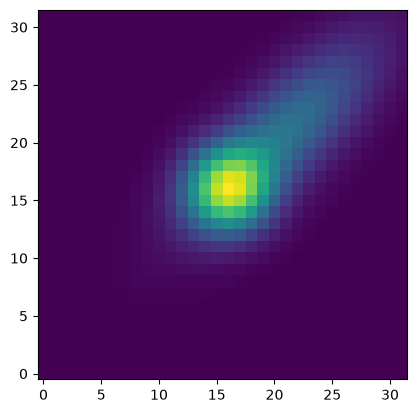

In [4]:
fig, ax = plt.subplots()
ax.imshow(example[(0, 0)], origin='lower')
plt.show()

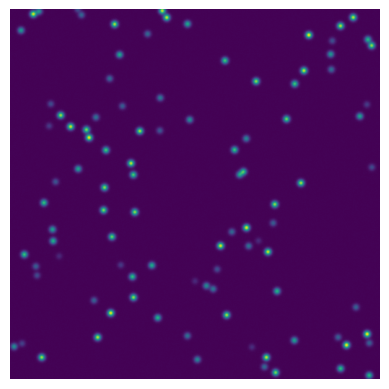

In [5]:
def simulate_perfect_image():
    model = Gaussian2D()
    shape = (img_size, img_size)
    n_sources = 100
    params = make_model_params(shape, n_sources, x_name='x_mean',
                               y_name='y_mean', min_separation=5,
                               amplitude=(100, 1000), x_stddev=(3, 3),
                               y_stddev=(3, 3), theta=(0, 0), seed=None)
    model_shape = (25, 25)
    image = make_model_image(shape, model, params, model_shape=model_shape,
                            x_name='x_mean', y_name='y_mean')
    image += np.random.uniform(-5, 5, size=image.shape)
    image = image.astype(float)
    return image

example_image = simulate_perfect_image()

fig, ax = plt.subplots()
ax.imshow(example_image, origin='lower')
ax.set_axis_off()
plt.show()

In [6]:
coords = calculate_covering((img_size, img_size), psf_size)
t = ArrayPSFTransform.construct(baked_in_initial_psf.as_array_psf(coords, psf_size),
                                synthetic_psf.as_array_psf(coords, psf_size), 1.0, 0.1)

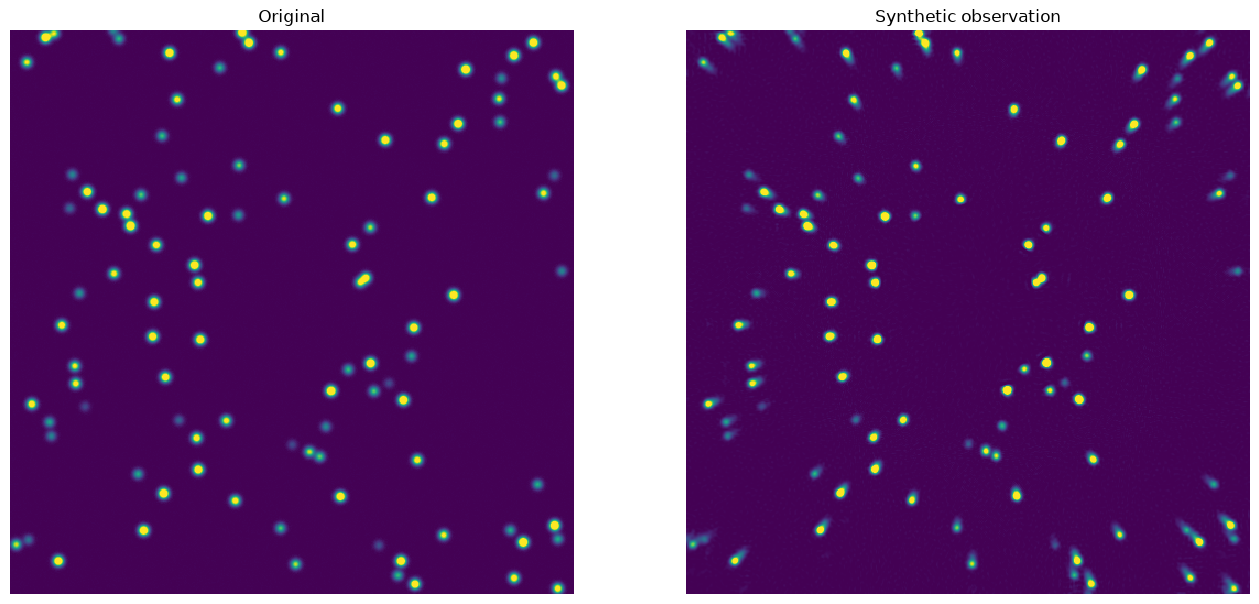

In [7]:
coma_image = t.apply(example_image)

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(16, 8))
axs[0].imshow(example_image, interpolation='None', vmin=0, vmax=500, origin='lower')
axs[1].imshow(coma_image, interpolation='None', vmin=0, vmax=500, origin='lower')
for ax in axs:
    ax.set_axis_off()
axs[0].set_title("Original")
axs[1].set_title("Synthetic observation")
plt.show()

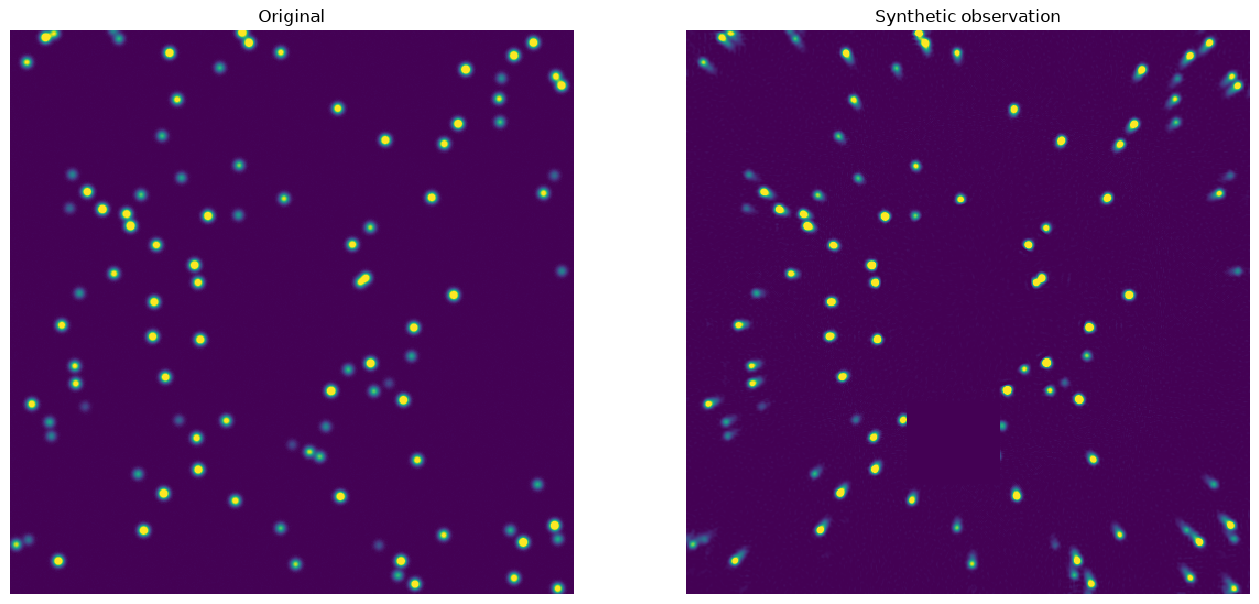

In [8]:
mask = np.zeros((img_size, img_size), dtype=bool)
mask[100:175, 200:285] = True

coma_image = t.apply(example_image)
coma_image[mask] = 0

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(16, 8))
axs[0].imshow(example_image, interpolation='None', vmin=0, vmax=500,  origin='lower')
axs[1].imshow(coma_image, interpolation='None', vmin=0, vmax=500,  origin='lower')
for ax in axs:
    ax.set_axis_off()
axs[0].set_title("Original")
axs[1].set_title("Synthetic observation")
plt.show()

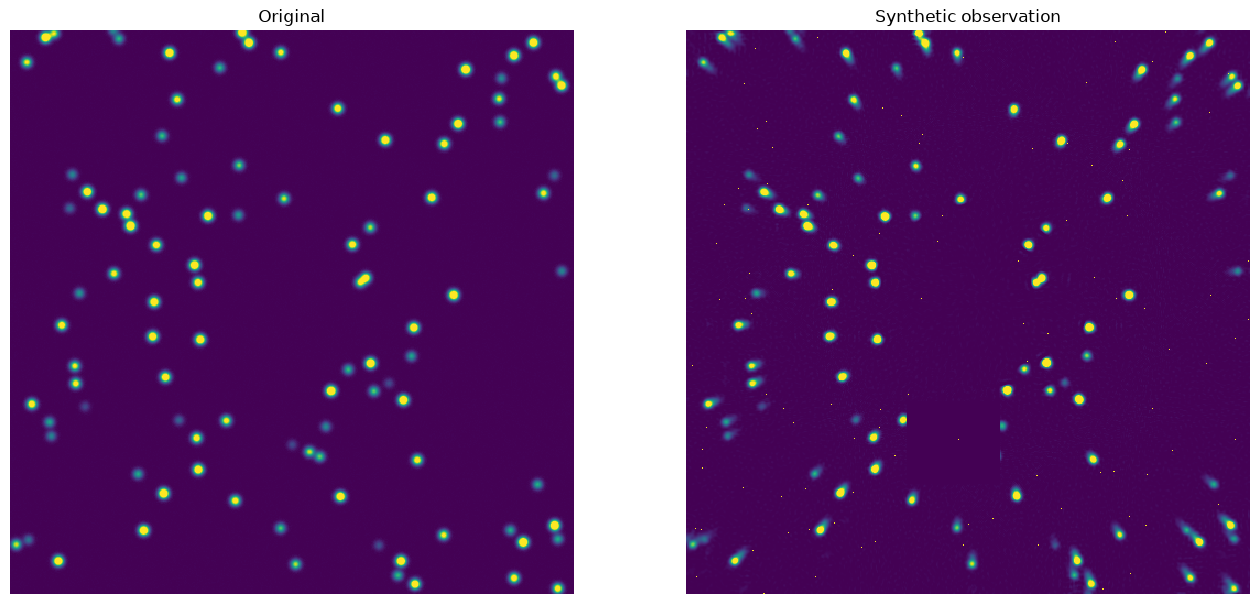

In [9]:
mask = np.zeros((img_size, img_size), dtype=bool)
mask[100:175, 200:285] = True

coma_image = t.apply(example_image)
coma_image[mask] = 0

cosmic_ray_pixels = np.random.randint(0, img_size, (100, 2))
coma_image[cosmic_ray_pixels[:, 0], cosmic_ray_pixels[:, 1]] = np.random.randint(2_000, 3_000, 100)

fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(16, 8))
axs[0].imshow(example_image, interpolation='None', vmin=0, vmax=500, origin='lower')
axs[1].imshow(coma_image, interpolation='None', vmin=0, vmax=500, origin='lower')
for ax in axs:
    ax.set_axis_off()
axs[0].set_title("Original")
axs[1].set_title("Synthetic observation")
plt.show()

In [10]:
mask = np.zeros((img_size, img_size), dtype=bool)
mask[100:175, 200:285] = True

def simulate_coma_image(t):
    coma_image = t.apply(simulate_perfect_image())
    coma_image[mask] = 0
    cosmic_ray_pixels = np.random.randint(0, img_size, (100, 2))
    coma_image[cosmic_ray_pixels[:, 0], cosmic_ray_pixels[:, 1]] = np.random.randint(2_000, 3_000, 100)
    return coma_image

images = np.array([simulate_coma_image(t) for _ in range(200)])

In [11]:
b = ArrayPSFBuilder(psf_size)
model, counts = b.build(images, saturation_threshold=1000, image_mask=mask)

/opt/anaconda3/envs/Perkins/lib/python3.14/site-packages/regularizepsf/builder.py:78: RuntimeWarning: All-NaN slice encountered
  percentile_method = lambda d: np.nanmedian(d, axis=0)
/opt/anaconda3/envs/Perkins/lib/python3.14/site-packages/regularizepsf/builder.py:258: RuntimeWarning: invalid value encountered in divide
  patch_corrected = patch_corrected / np.nansum(patch_corrected)


<Axes: xlabel='Patch number', ylabel='Patch number'>

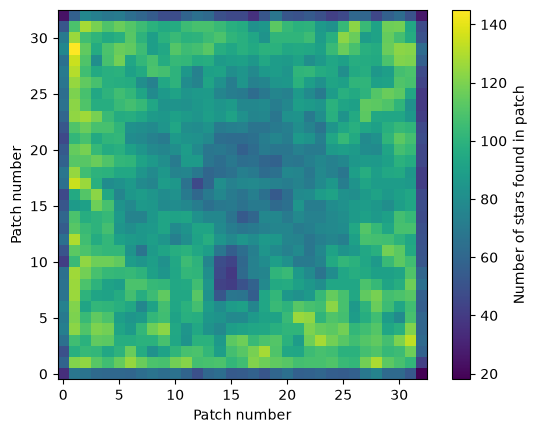

In [12]:
visualize_patch_counts(counts)

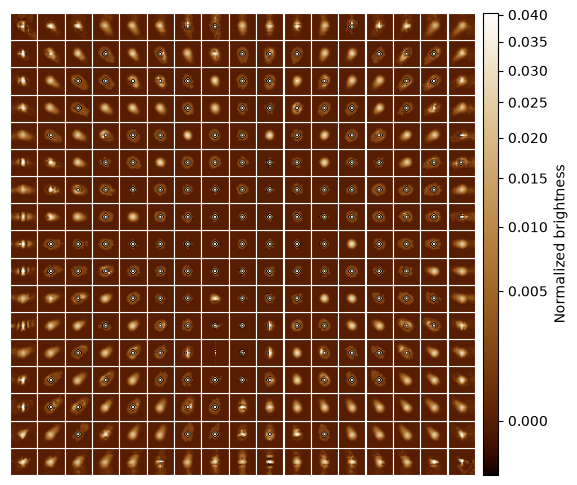

In [13]:
model.visualize_psfs(patch_stride=2)


In [14]:
b_bad = ArrayPSFBuilder(psf_size)
model_bad, counts_bad = b_bad.build(images)


<Axes: xlabel='Patch number', ylabel='Patch number'>

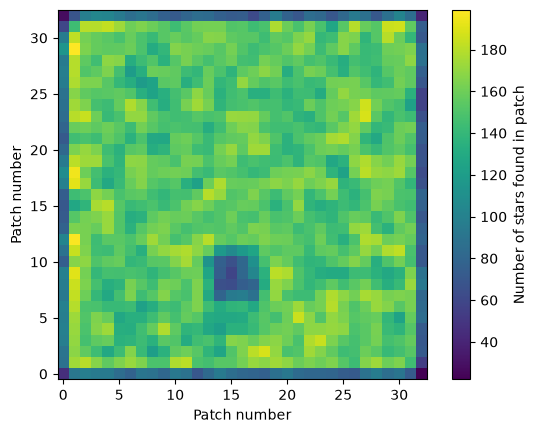

In [15]:
visualize_patch_counts(counts_bad)

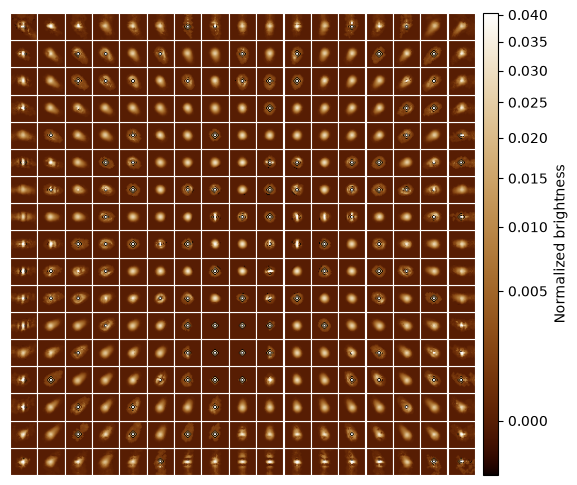

In [16]:
model_bad.visualize_psfs(patch_stride=2)

In [17]:
@simple_functional_psf
def uniform_psf(row,
             col,
             x0=psf_size / 2,
             y0=psf_size / 2,
             sigma_x=3.0,
             sigma_y=3.0,
             A=1.0/(2 * np.pi * 3 * 3)):
    return A * np.exp(-(np.square(row - x0) / (2 * np.square(sigma_x)) + np.square(col - y0) / (2 * np.square(sigma_y))))

#correcter = ArrayPSFTransform.construct(model, uniform_psf.as_array_psf(coords, psf_size), 1.0, 0.1)
#corrected_images = np.array([correcter.apply(image, saturation_threshold=2_000) for image in images])

NameError: name 'corrected_images' is not defined

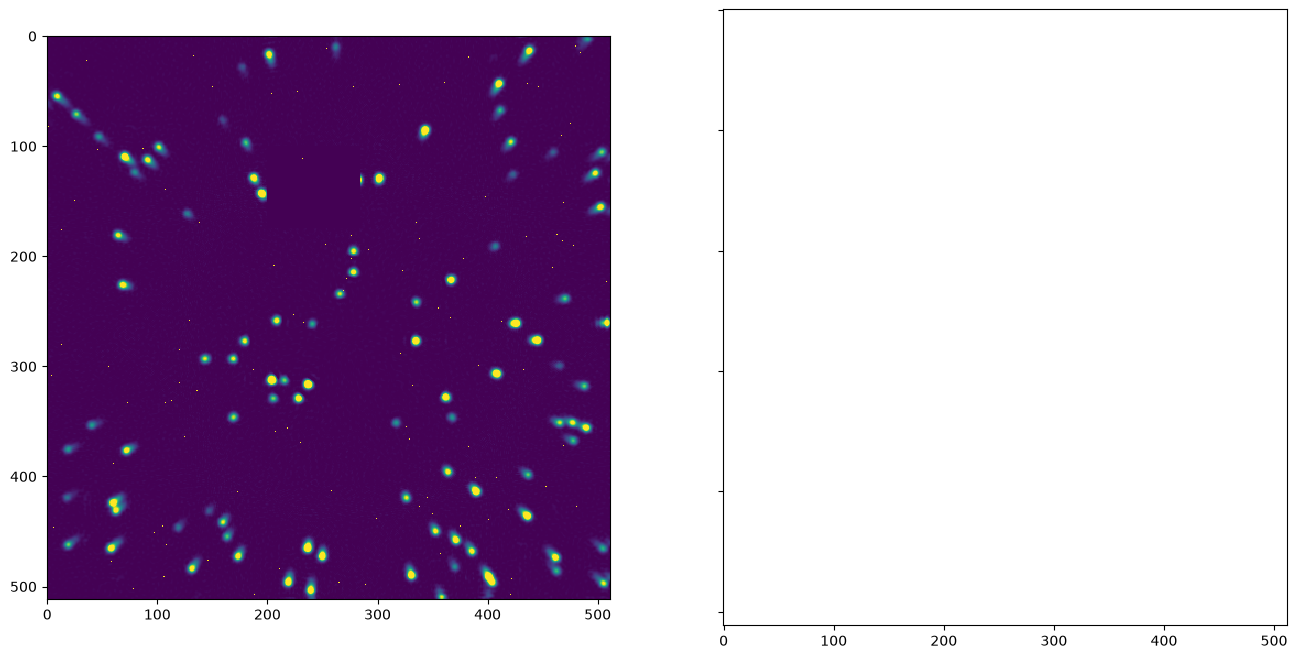

In [18]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(16, 8))
axs[0].imshow(images[0], interpolation='None', vmin=0, vmax=500)
axs[1].imshow(corrected_images[0], interpolation='None', vmin=0, vmax=500)
for ax in axs:
    ax.set_axis_off()
axs[0].set_title("Observation")
axs[1].set_title("Corrected image")
plt.show()

In [19]:
data = fits.getdata("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250318/standard/HaOFF/registered_New H Alpha (Off).fits")
np.shape(data)
data = data[10:2055,::]
print(np.shape(data))

(2045, 2045)


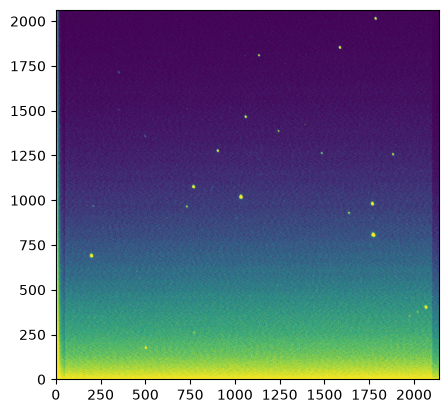

In [20]:
data1 = fits.getdata("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250318/standard/HaOFF/20250318.140.fits")

plt.figure()
plt.imshow(data1,vmin=1150,vmax=1175,origin='lower')

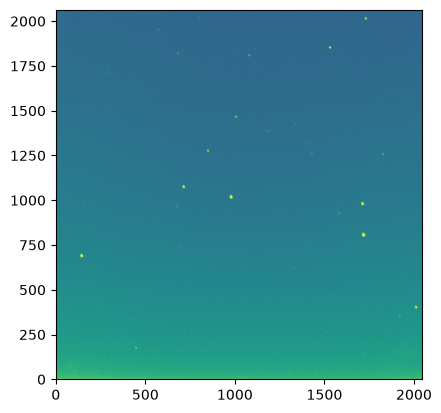

In [21]:
data2 = fits.getdata("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250318/standard/HaOFF/fdb_20250318.140.fits")

plt.figure()
plt.imshow(data2,vmin=0.00,vmax=100,origin='lower')

In [22]:
image_s_n_fdb_HaOFF = glob.glob("/Users/samkleiman/Desktop/PERKINS_DATA_TESTING/20250318/standard/HaON/newreg_s_n_fdb*")
data = []
for path in image_s_n_fdb_HaOFF:
    im_data = fits.getdata(path)
    im_data = im_data[11:2055,1:]
    data.append(im_data)
data = np.array(data)



In [23]:
len(data)

11

In [ ]:
psf_size=1022
builder = ArrayPSFBuilder(psf_size)
my_model, my_counts = builder.build(data, saturation_threshold=100)

In [ ]:
visualize_patch_counts(my_counts)

In [ ]:
my_model.visualize_psfs(edge_trim=450)

In [ ]:
coords = calculate_covering((2044, 2044), psf_size)
t = ArrayPSFTransform.construct(baked_in_initial_psf.as_array_psf(coords, psf_size),
                                synthetic_psf.as_array_psf(coords, psf_size), 1, 0.1)

In [ ]:
correcter = ArrayPSFTransform.construct(my_model, uniform_psf.as_array_psf(coords, psf_size), 1, 0.1)
corrected_ims = np.array([correcter.apply(im_data, saturation_threshold=50) for im_data in data])

In [ ]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(16, 8))
axs[0].imshow(data[0], interpolation='None', vmin=0, vmax=1)
axs[1].imshow(corrected_ims[0], interpolation='None', vmin=0, vmax=1)
for ax in axs:
    ax.set_axis_off()
axs[0].set_title("Observation")
axs[1].set_title("Corrected image")
plt.show()

In [ ]:
fits.writeto("/Users/samkleiman/Desktop/PSF_REGULARIZED2.fits",corrected_ims[0])